In [80]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

# Load cleaned data (for IDs and later merging)
df = pd.read_csv("../data/processed/uniswap_v3_usdc_weth_swaps_processed.csv")

# Load scaled features (for model input)
X_scaled = np.load("../data/processed/X_scaled.npy")

# Load feature names (optional, for interpretation)
with open("../data/processed/feature_names.txt") as f:
    numeric_features = [line.strip() for line in f]

assert X_scaled.shape[1] == len(numeric_features)

print("Data shape:", X_scaled.shape)
print("Number of features:", len(numeric_features))


Data shape: (1000, 7)
Number of features: 7


In [81]:
from sklearn.ensemble import IsolationForest

# Select scaled features for anomaly detection
scaled_features = [f"{col}_scaled" for col in numeric_features]
X_scaled_for_if = X_scaled

# Build and fit the Isolation Forest model
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # assume ~5% anomalies
    random_state=42
)

iso_labels = iso_model.fit_predict(X_scaled_for_if)

# Add anomaly labels back into dataset
df["isolation_forest_anomaly"] = iso_labels


In [82]:
anomalies = df[df["isolation_forest_anomaly"] == -1]
normal = df[df["isolation_forest_anomaly"] == 1]

print("Anomaly count:", len(anomalies))
print("Normal count:", len(normal))


Anomaly count: 50
Normal count: 950


In [83]:
# Build scaled DataFrame for interpretation
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=numeric_features,
    index=df.index
)

# Split normal vs anomaly
normal_scaled = X_scaled_df[df["isolation_forest_anomaly"] == 1]
anomalies_scaled = X_scaled_df[df["isolation_forest_anomaly"] == -1]

# Compare feature means
feature_means = pd.DataFrame({
    "Normal Mean": normal_scaled.mean(),
    "Anomaly Mean": anomalies_scaled.mean()
})

feature_means



,Normal Mean,Anomaly Mean
amount0,0.005136,-26.647223
amount1,-0.003886,26.680018
sqrtPriceX96,-0.276475,-0.601545
liquidity,15.342616,1550.200562
tick,-0.271649,-0.601333
gasPrice,1.232260,12.792939
gasUsed,0.283071,5.001079


In [84]:
top_anomaly_senders = anomalies["sender"].value_counts().head(5)
top_anomaly_recipients = anomalies["recipient"].value_counts().head(5)

top_anomaly_senders, top_anomaly_recipients


(sender
 0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad    17
 0xe8cfad4c75a5e1caf939fd80afcf837dde340a69    14
 0xe592427a0aece92de3edee1f18e0157c05861564     7
 0xdef1c0ded9bec7f1a1670819833240f027b25eff     3
 0x51c72848c68a965f66fa7a88855f9f7784502a7f     2
 Name: count, dtype: int64,
 recipient
 0xe8cfad4c75a5e1caf939fd80afcf837dde340a69    14
 0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad    11
 0x638a98bbb92a7582d07c52ff407d49664dc8b3ee     3
 0xdef171fe48cf0115b1d80b88dc8eab59176fee57     3
 0x51c72848c68a965f66fa7a88855f9f7784502a7f     2
 Name: count, dtype: int64)

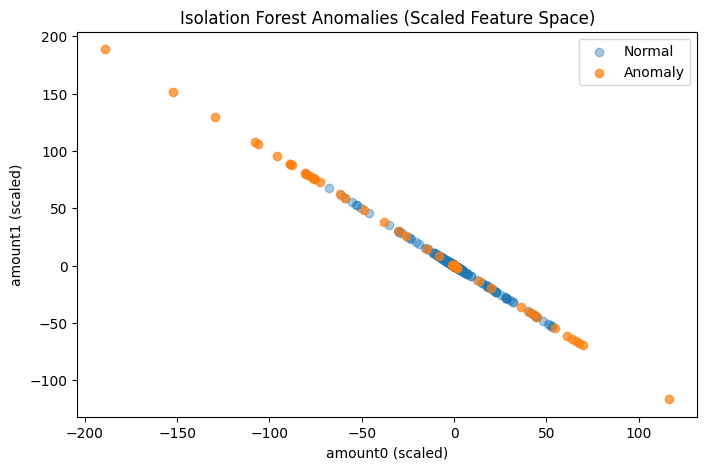

In [85]:
plt.figure(figsize=(8, 5))

plt.scatter(
    normal_scaled["amount0"],
    normal_scaled["amount1"],
    alpha=0.4,
    label="Normal"
)

plt.scatter(
    anomalies_scaled["amount0"],
    anomalies_scaled["amount1"],
    alpha=0.7,
    label="Anomaly"
)

plt.xlabel("amount0 (scaled)")
plt.ylabel("amount1 (scaled)")
plt.legend()
plt.title("Isolation Forest Anomalies (Scaled Feature Space)")
plt.show()



C:\Users\Mina\AppData\Local\Temp\ipykernel_6992\2392972857.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["timeStamp_dt"] = pd.to_datetime(anomalies["timeStamp_dt"])
C:\Users\Mina\AppData\Local\Temp\ipykernel_6992\2392972857.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("H")


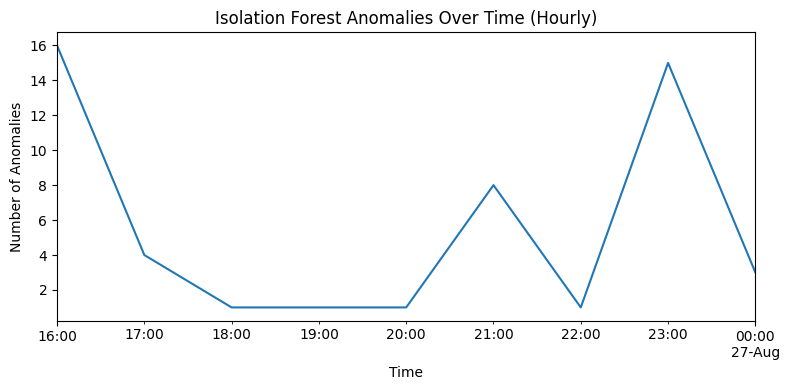

In [86]:
# Ensure datetime index
anomalies["timeStamp_dt"] = pd.to_datetime(anomalies["timeStamp_dt"])

anomalies_per_hour = (
    anomalies
    .set_index("timeStamp_dt")
    .resample("H")
    .size()
)

plt.figure(figsize=(8, 4))
anomalies_per_hour.plot()
plt.title("Isolation Forest Anomalies Over Time (Hourly)")
plt.ylabel("Number of Anomalies")
plt.xlabel("Time")
plt.tight_layout()
plt.show()



In [87]:
# Isolation Forest anomaly scores (higher = more anomalous after sign flip)
anomaly_scores = iso_model.decision_function(X_scaled_for_if)

df["isolation_score"] = -anomaly_scores  # flip so larger = more anomalous

print("Isolation Forest anomaly score summary:\n")
print(df["isolation_score"].describe())


Isolation Forest anomaly score summary:

count    1000.000000
mean       -0.165725
std         0.068196
min        -0.224304
25%        -0.207184
50%        -0.186941
75%        -0.163931
max         0.200054
Name: isolation_score, dtype: float64


In [88]:
print("\nTop 5 highest-risk anomalies:\n")
cols_to_show = ["sender", "recipient", "amount0", "amount1", "liquidity", "gasPrice", "isolation_score"]
print(df.sort_values("isolation_score", ascending=False).head(5)[cols_to_show])


Top 5 highest-risk anomalies:

                                         sender  \
16   0xe8cfad4c75a5e1caf939fd80afcf837dde340a69   
31   0xe8cfad4c75a5e1caf939fd80afcf837dde340a69   
901  0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0   
889  0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad   
819  0xe8cfad4c75a5e1caf939fd80afcf837dde340a69   

                                      recipient       amount0  \
16   0xe8cfad4c75a5e1caf939fd80afcf837dde340a69 -421800456347   
31   0xe8cfad4c75a5e1caf939fd80afcf837dde340a69 -523931437876   
901  0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0 -265430999843   
889  0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad -222018850285   
819  0xe8cfad4c75a5e1caf939fd80afcf837dde340a69 -358847328580   

                   amount1               liquidity      gasPrice  \
16   255828679014122873255    42650691009184698025  0x38e5e5d377   
31   318093935332575067681    36436129027849465614  0x97c6c186fc   
901  161460000000000000000   834267773667859163307   0x2a05c99b7  

In [89]:
from sklearn.cluster import KMeans

# Use scaled features for anomaly clustering
anom_scaled = X_scaled_df[df["isolation_forest_anomaly"] == -1]


kmeans = KMeans(n_clusters=2, random_state=42)
anom_scaled["anomaly_group"] = kmeans.fit_predict(anom_scaled)


# Optional: see how many in each group
anom_scaled["anomaly_group"].value_counts()


C:\Users\Mina\AppData\Local\Temp\ipykernel_6992\2309953026.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anom_scaled["anomaly_group"] = kmeans.fit_predict(anom_scaled)


anomaly_group
1    39
0    11
Name: count, dtype: int64

In [90]:
cluster_profiles = anom_scaled.groupby("anomaly_group").mean()
cluster_profiles


,amount0,amount1,sqrtPriceX96,liquidity,tick,gasPrice,gasUsed
anomaly_group,,,,,,,
0,-42.266502,42.347505,-0.016700,6471.036980,-0.006061,-0.369953,1.306436
1,-22.241785,22.260983,-0.766502,162.272342,-0.769231,16.505550,6.043158


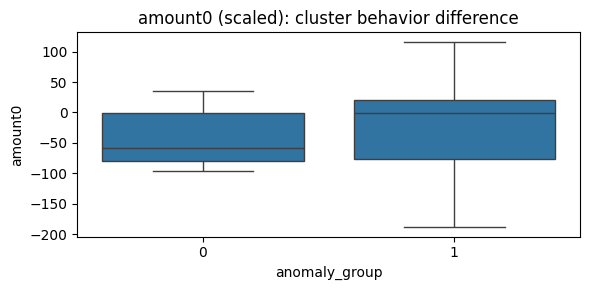

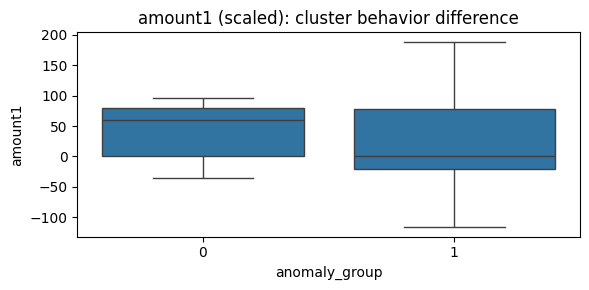

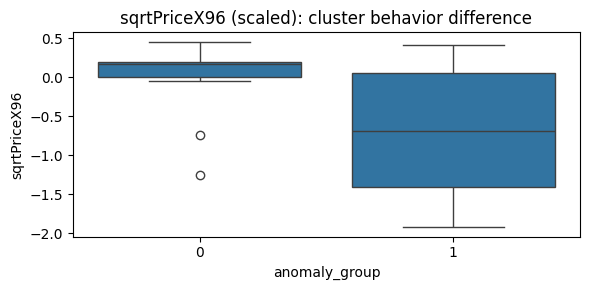

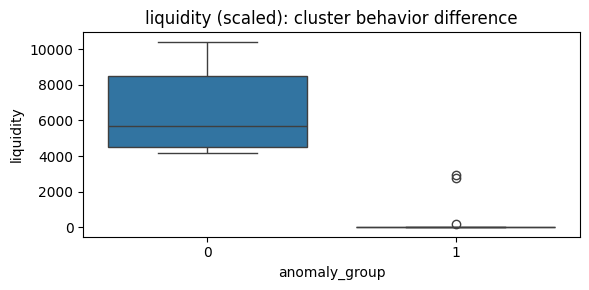

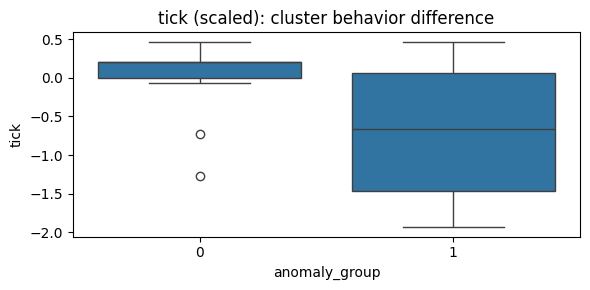

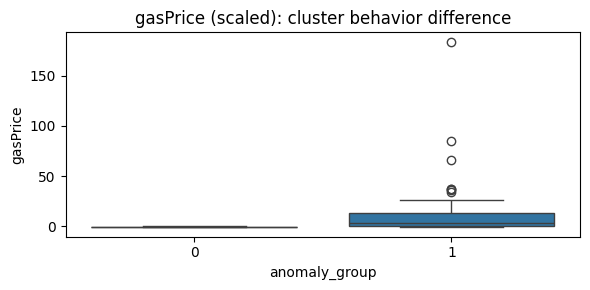

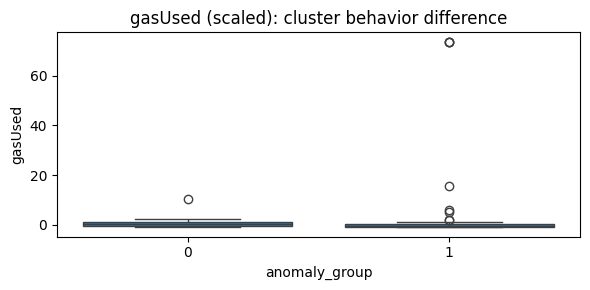

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_features:
    plt.figure(figsize=(6, 3))
    sns.boxplot(
        data=anom_scaled,
        x="anomaly_group",
        y=col
    )
    plt.title(f"{col} (scaled): cluster behavior difference")
    plt.tight_layout()
    plt.show()


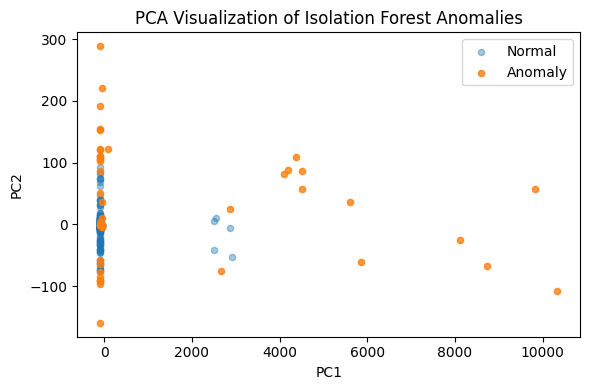

In [92]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# PCA on scaled features
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_scaled)

# Store PCA results in DataFrame
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"],
    index=df.index
)

# Attach anomaly labels
pca_df["isolation_forest_anomaly"] = df["isolation_forest_anomaly"]

# Plot
plt.figure(figsize=(6, 4))

plt.scatter(
    pca_df[pca_df["isolation_forest_anomaly"] == 1]["PC1"],
    pca_df[pca_df["isolation_forest_anomaly"] == 1]["PC2"],
    s=20, alpha=0.4, label="Normal"
)

plt.scatter(
    pca_df[pca_df["isolation_forest_anomaly"] == -1]["PC1"],
    pca_df[pca_df["isolation_forest_anomaly"] == -1]["PC2"],
    s=20, alpha=0.8, label="Anomaly"
)

plt.legend()
plt.title("PCA Visualization of Isolation Forest Anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


In [93]:
# =========================
# SAVE ISOLATION FOREST RESULTS
# =========================

# 1) Save main Isolation Forest results
if_results = df[[
    "transactionHash",
    "isolation_forest_anomaly",
    "isolation_score"
]]

if_results.to_csv(
    "../results/isolation_forest_results.csv",
    index=False
)

print("Saved: isolation_forest_results.csv")


# 2) Save indices of NORMAL data for Autoencoder
normal_indices = df.index[df["isolation_forest_anomaly"] == 1].to_numpy()

np.save(
    "../results/if_normal_indices.npy",
    normal_indices
)

print(f"Saved normal indices for Autoencoder: {len(normal_indices)} samples")


# 3) (Optional) Save anomaly cluster labels
if "anomaly_group" in anom_scaled.columns:
    anomaly_groups_df = df.loc[
        df["isolation_forest_anomaly"] == -1,
        ["transactionHash"]
    ].copy()

    anomaly_groups_df["anomaly_group"] = anom_scaled["anomaly_group"].values

    anomaly_groups_df.to_csv(
        "../results/if_anomaly_clusters.csv",
        index=False
    )

    print("Saved: if_anomaly_clusters.csv")


Saved: isolation_forest_results.csv
Saved normal indices for Autoencoder: 950 samples
Saved: if_anomaly_clusters.csv
